# Финальный проект. Этап 3 — Анализ данных

**Цель этапа:** выявить закономерности и точки роста бизнеса:
динамика во времени, эффективность каналов и кампаний,
работа менеджеров, популярность продуктов, география продаж.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

**План:**
1. Загрузка данных и подготовка дат
2. Временные ряды: динамика создания сделок
3. Временные ряды: звонки и их связь со сделками
4. Время жизни сделки: от создания до закрытия
5. Анализ маркетинговых кампаний: лиды и конверсия
6. Анализ источников трафика: качество лидов
7. Анализ менеджеров по продажам
8. Продукты и платежи
9. География: города и уровень немецкого
10. Сводные бизнес-выводы


## 1. Загрузка данных и подготовка дат

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [2]:
DATA_CLEAN = '../data_clean/'
PLOTS = '../data_clean/plots/'

deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False)
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False)
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Загружено:')
print(f'  Deals:  {deals.shape}')
print(f'  Calls:  {calls.shape}')
print(f'  Spend:  {spend.shape}')


Загружено:
  Deals:  (21593, 27)
  Calls:  (95874, 9)
  Spend:  (19862, 8)


In [3]:
# Конвертируем даты — в CSV они хранятся как строки
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], errors='coerce')
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])
spend['Date'] = pd.to_datetime(spend['Date'])

# Добавляем удобные временные признаки для группировки
deals['Created Month'] = deals['Created Time'].dt.to_period('M')
deals['Created Week'] = deals['Created Time'].dt.to_period('W')
deals['Created Day'] = deals['Created Time'].dt.date

calls['Call Month'] = calls['Call Start Time'].dt.to_period('M')

print('Типы дат после конвертации:')
print(f'  Created Time: {deals["Created Time"].dtype}')
print(f'  Call Start:   {calls["Call Start Time"].dtype}')
print(f'  Spend Date:   {spend["Date"].dtype}')


Типы дат после конвертации:
  Created Time: datetime64[ns]
  Call Start:   datetime64[ns]
  Spend Date:   datetime64[ns]


## 2. Временные ряды: динамика создания сделок

Смотрим, как менялся поток лидов со временем —
это позволяет увидеть сезонность, пики активности и провалы.


In [4]:
# Группируем по месяцам — агрегируем число сделок
monthly_deals = (
    deals.groupby('Created Month')
    .size()
    .reset_index(name='Deals Count')
)

# Period → datetime для корректного отображения на графике
monthly_deals['Month'] = monthly_deals['Created Month'].dt.to_timestamp()

print('Сделки по месяцам:')
print(monthly_deals[['Month', 'Deals Count']].to_string(index=False))


Сделки по месяцам:
     Month  Deals Count
2023-07-01          654
2023-08-01         1085
2023-09-01         1079
2023-10-01         1598
2023-11-01         1947
2023-12-01         1811
2024-01-01         2243
2024-02-01         2184
2024-03-01         2252
2024-04-01         3082
2024-05-01         1984
2024-06-01         1674


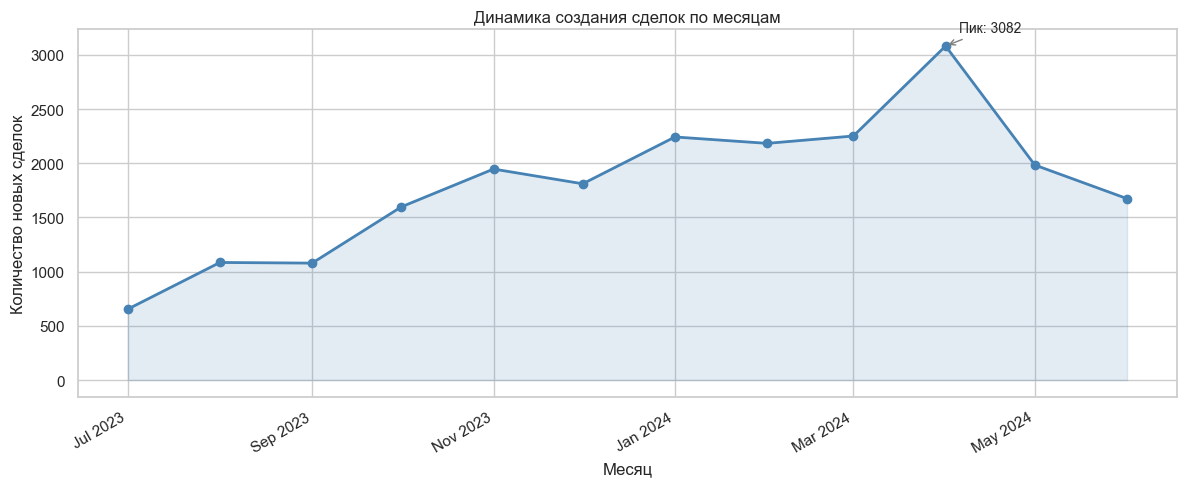

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_deals['Month'], monthly_deals['Deals Count'],
                alpha=0.15, color='steelblue')

ax.set_title('Динамика создания сделок по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество новых сделок')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

# Помечаем пик
peak_idx = monthly_deals['Deals Count'].idxmax()
peak_row = monthly_deals.loc[peak_idx]
ax.annotate(f'Пик: {peak_row["Deals Count"]}',
            xy=(peak_row['Month'], peak_row['Deals Count']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_monthly.png', dpi=100)
plt.show()


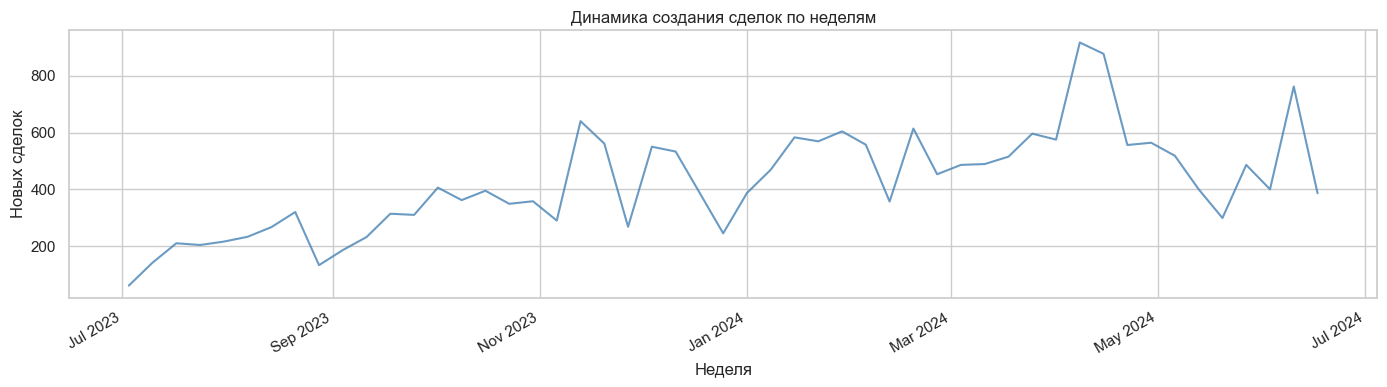

In [6]:
# Недельная динамика — видны краткосрочные колебания
weekly_deals = (
    deals.groupby('Created Week')
    .size()
    .reset_index(name='Deals Count')
)
weekly_deals['Week'] = weekly_deals['Created Week'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_deals['Week'], weekly_deals['Deals Count'],
        linewidth=1.5, color='steelblue', alpha=0.8)
ax.set_title('Динамика создания сделок по неделям')
ax.set_xlabel('Неделя')
ax.set_ylabel('Новых сделок')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_weekly.png', dpi=100)
plt.show()


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_36096\393671683.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_conv = deals.groupby('Created Month').apply(


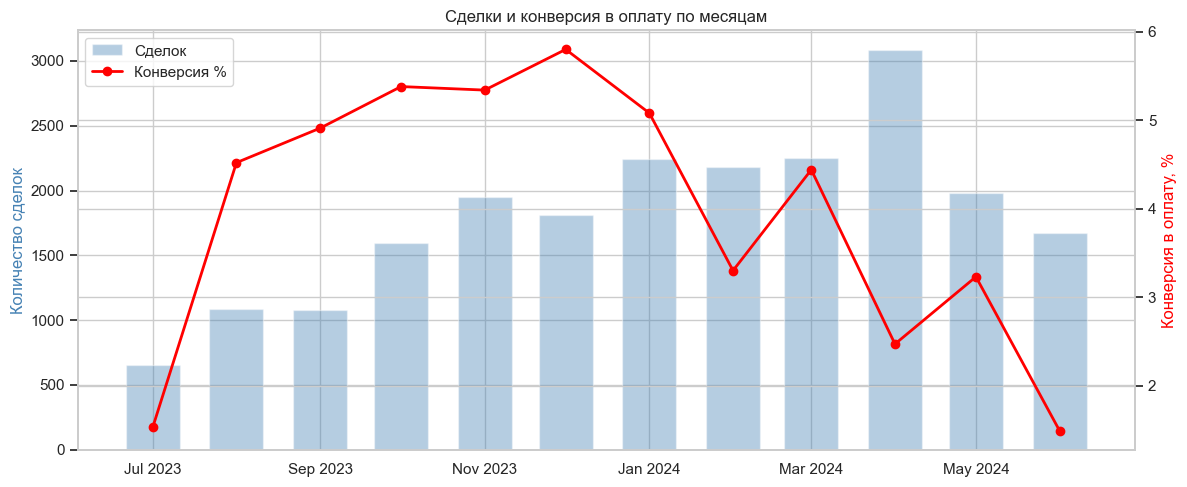

In [7]:
# Конверсия по месяцам — растёт ли качество со временем?
monthly_conv = deals.groupby('Created Month').apply(
    lambda x: pd.Series({
        'Deals': len(x),
        'Paid': (x['Stage'] == 'Payment Done').sum(),
        'Conversion %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    })
).reset_index()
monthly_conv['Month'] = monthly_conv['Created Month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Ось 1: число сделок (столбцы)
ax1.bar(monthly_conv['Month'], monthly_conv['Deals'],
        width=20, color='steelblue', alpha=0.4, label='Сделок')
ax1.set_ylabel('Количество сделок', color='steelblue')

# Ось 2: конверсия (линия)
ax2 = ax1.twinx()
ax2.plot(monthly_conv['Month'], monthly_conv['Conversion %'],
         color='red', marker='o', linewidth=2, label='Конверсия %')
ax2.set_ylabel('Конверсия в оплату, %', color='red')

ax1.set_title('Сделки и конверсия в оплату по месяцам')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_conversion_monthly.png', dpi=100)
plt.show()


In [8]:
# Выводим таблицу с лучшими и худшими месяцами по конверсии
print('Конверсия по месяцам (сортировка по убыванию):')
print(monthly_conv[['Month', 'Deals', 'Paid', 'Conversion %']]
      .sort_values('Conversion %', ascending=False)
      .to_string(index=False))


Конверсия по месяцам (сортировка по убыванию):
     Month  Deals  Paid  Conversion %
2023-12-01 1811.0 105.0          5.80
2023-10-01 1598.0  86.0          5.38
2023-11-01 1947.0 104.0          5.34
2024-01-01 2243.0 114.0          5.08
2023-09-01 1079.0  53.0          4.91
2023-08-01 1085.0  49.0          4.52
2024-03-01 2252.0 100.0          4.44
2024-02-01 2184.0  72.0          3.30
2024-05-01 1984.0  64.0          3.23
2024-04-01 3082.0  76.0          2.47
2023-07-01  654.0  10.0          1.53
2024-06-01 1674.0  25.0          1.49


## 3. Динамика звонков и её связь со сделками

In [9]:
# Звонки по месяцам
monthly_calls = (
    calls.groupby('Call Month')
    .size()
    .reset_index(name='Calls Count')
)
monthly_calls['Month'] = monthly_calls['Call Month'].dt.to_timestamp()

print('Звонки по месяцам:')
print(monthly_calls[['Month', 'Calls Count']].to_string(index=False))


Звонки по месяцам:
     Month  Calls Count
2023-06-01            7
2023-07-01         1935
2023-08-01         4251
2023-09-01         5156
2023-10-01         7102
2023-11-01         7170
2023-12-01         7099
2024-01-01         9804
2024-02-01         9599
2024-03-01        10081
2024-04-01        13328
2024-05-01        11847
2024-06-01         8495


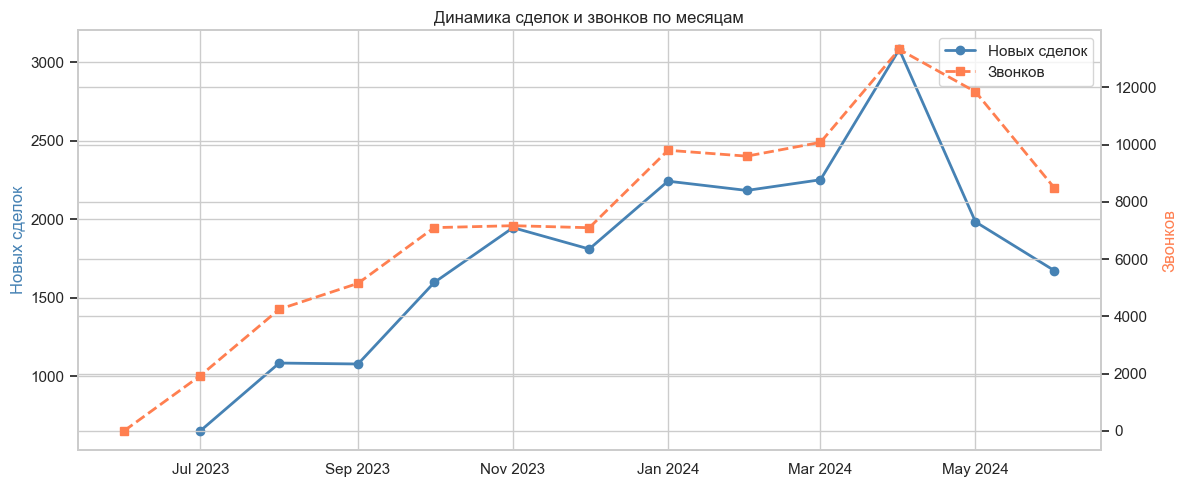

In [10]:
# Сравниваем динамику сделок и звонков на одном графике
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
         marker='o', linewidth=2, color='steelblue', label='Новых сделок')
ax1.set_ylabel('Новых сделок', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_calls['Month'], monthly_calls['Calls Count'],
         marker='s', linewidth=2, color='coral', linestyle='--', label='Звонков')
ax2.set_ylabel('Звонков', color='coral')

ax1.set_title('Динамика сделок и звонков по месяцам')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_vs_calls.png', dpi=100)
plt.show()


In [11]:
# Среднее число звонков на сделку по месяцам
merged = pd.merge(
    monthly_deals[['Month', 'Deals Count']],
    monthly_calls[['Month', 'Calls Count']],
    on='Month', how='inner'
)
merged['Calls per Deal'] = (merged['Calls Count'] / merged['Deals Count']).round(1)
print('Звонков на одну сделку по месяцам:')
print(merged[['Month', 'Deals Count', 'Calls Count', 'Calls per Deal']].to_string(index=False))


Звонков на одну сделку по месяцам:
     Month  Deals Count  Calls Count  Calls per Deal
2023-07-01          654         1935             3.0
2023-08-01         1085         4251             3.9
2023-09-01         1079         5156             4.8
2023-10-01         1598         7102             4.4
2023-11-01         1947         7170             3.7
2023-12-01         1811         7099             3.9
2024-01-01         2243         9804             4.4
2024-02-01         2184         9599             4.4
2024-03-01         2252        10081             4.5
2024-04-01         3082        13328             4.3
2024-05-01         1984        11847             6.0
2024-06-01         1674         8495             5.1


## 4. Время жизни сделки: от создания до закрытия

Анализируем, сколько дней проходит от создания сделки до её закрытия.
Сравниваем Payment Done (успешные) и Lost (проигранные).


In [12]:
# Вычисляем время жизни сделки в днях
# Используем только строки без ошибки в Closing Date
closed = deals[
    deals['Closing Date'].notna() & (deals['closing_date_error'] == False)
].copy()

closed['Days to Close'] = (
    closed['Closing Date'] - closed['Created Time']
).dt.days

print(f'Закрытых сделок (без ошибок в дате): {len(closed)}')
print()
print('Время жизни сделки (в днях):')
print(closed.groupby('Stage')['Days to Close']
      .describe().round(1)
      .to_string())


Закрытых сделок (без ошибок в дате): 14601

Время жизни сделки (в днях):
                         count  mean   std  min  25%   50%   75%    max
Stage                                                                  
Call Delayed             228.0  23.6  45.0 -1.0  0.0   3.0  27.2  287.0
Lost                   13818.0  13.2  30.5 -1.0  0.0   2.0  10.0  334.0
Need to Call - Sales       2.0   3.0   1.4  2.0  2.5   3.0   3.5    4.0
Payment Done             517.0  32.5  43.0 -1.0  6.0  16.0  42.0  304.0
Qualificated               2.0   1.0   1.4  0.0  0.5   1.0   1.5    2.0
Registered on Webinar      3.0   1.3   2.5 -1.0  0.0   1.0   2.5    4.0
Test Sent                  2.0   7.5   6.4  3.0  5.2   7.5   9.8   12.0
Waiting For Payment       29.0  10.8  25.6 -1.0  0.0   1.0   6.0  105.0


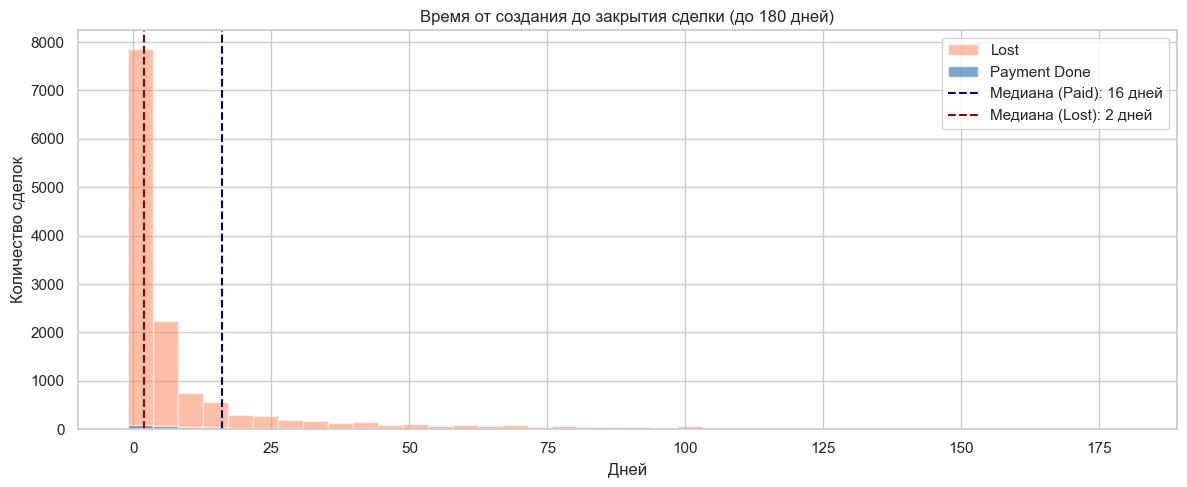

In [13]:
# Сравниваем распределение для Payment Done и Lost
paid_days = closed.loc[closed['Stage'] == 'Payment Done', 'Days to Close'].dropna()
lost_days = closed.loc[closed['Stage'] == 'Lost', 'Days to Close'].dropna()

# Ограничиваем до 180 дней — убираем крайние выбросы
paid_trimmed = paid_days[paid_days <= 180]
lost_trimmed = lost_days[lost_days <= 180]

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(lost_trimmed, bins=40, alpha=0.5, color='coral', label='Lost')
ax.hist(paid_trimmed, bins=40, alpha=0.7, color='steelblue', label='Payment Done')

ax.axvline(paid_trimmed.median(), color='navy', linestyle='--',
           label=f'Медиана (Paid): {paid_trimmed.median():.0f} дней')
ax.axvline(lost_trimmed.median(), color='darkred', linestyle='--',
           label=f'Медиана (Lost): {lost_trimmed.median():.0f} дней')

ax.set_title('Время от создания до закрытия сделки (до 180 дней)')
ax.set_xlabel('Дней')
ax.set_ylabel('Количество сделок')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'deal_lifecycle.png', dpi=100)
plt.show()


In [14]:
print(f'Медиана дней до оплаты:  {paid_trimmed.median():.0f}')
print(f'Медиана дней до потери:  {lost_trimmed.median():.0f}')
print()
print('Вывод: оплата происходит быстрее, чем "потеря".')
print('Это логично: клиент либо решает быстро, либо затягивает и уходит.')


Медиана дней до оплаты:  16
Медиана дней до потери:  2

Вывод: оплата происходит быстрее, чем "потеря".
Это логично: клиент либо решает быстро, либо затягивает и уходит.


## 5. Анализ маркетинговых кампаний

Оцениваем эффективность кампаний: сколько лидов привлекают
и какой процент из них конвертируется в оплату.


In [15]:
# Оставляем только сделки с заполненной кампанией
with_campaign = deals[deals['Campaign'].notna()].copy()
print(f'Сделок с кампанией: {len(with_campaign)} из {len(deals)}')


Сделок с кампанией: 16067 из 21593


In [16]:
# Агрегируем по кампаниям
campaign_stats = (
    with_campaign.groupby('Campaign')
    .apply(lambda x: pd.Series({
        'Лидов': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False)
    .reset_index()
    .sort_values('Лидов', ascending=False)
)

# Показываем топ-20 по числу лидов
print('Топ кампаний по числу лидов (топ-20):')
print(campaign_stats.head(20).to_string(index=False))


Топ кампаний по числу лидов (топ-20):
                         Campaign  Лидов  Оплат  Конверсия %
performancemax_digitalmarkt_ru_DE 2653.0  112.0         4.22
                youtube_shorts_DE 1635.0   53.0         3.24
                12.07.2023wide_DE 1575.0   48.0         3.05
                  02.07.23wide_DE  975.0   52.0         5.33
         04.07.23recentlymoved_DE  750.0   31.0         4.13
                    03.07.23women  612.0   31.0         5.07
                           Dis_DE  581.0   30.0         5.16
                   07.07.23LAL_DE  542.0   28.0         5.17
        12.09.23interests_Uxui_DE  531.0   27.0         5.08
           24.09.23retargeting_DE  479.0   17.0         3.55
                      webinar1604  343.0    3.0         0.87
                          work_DE  317.0   10.0         3.15
                      webinar1906  290.0    0.0         0.00
          08.04.24wide_webinar_DE  284.0    1.0         0.35
                         blog2_DE  273.0    6.0

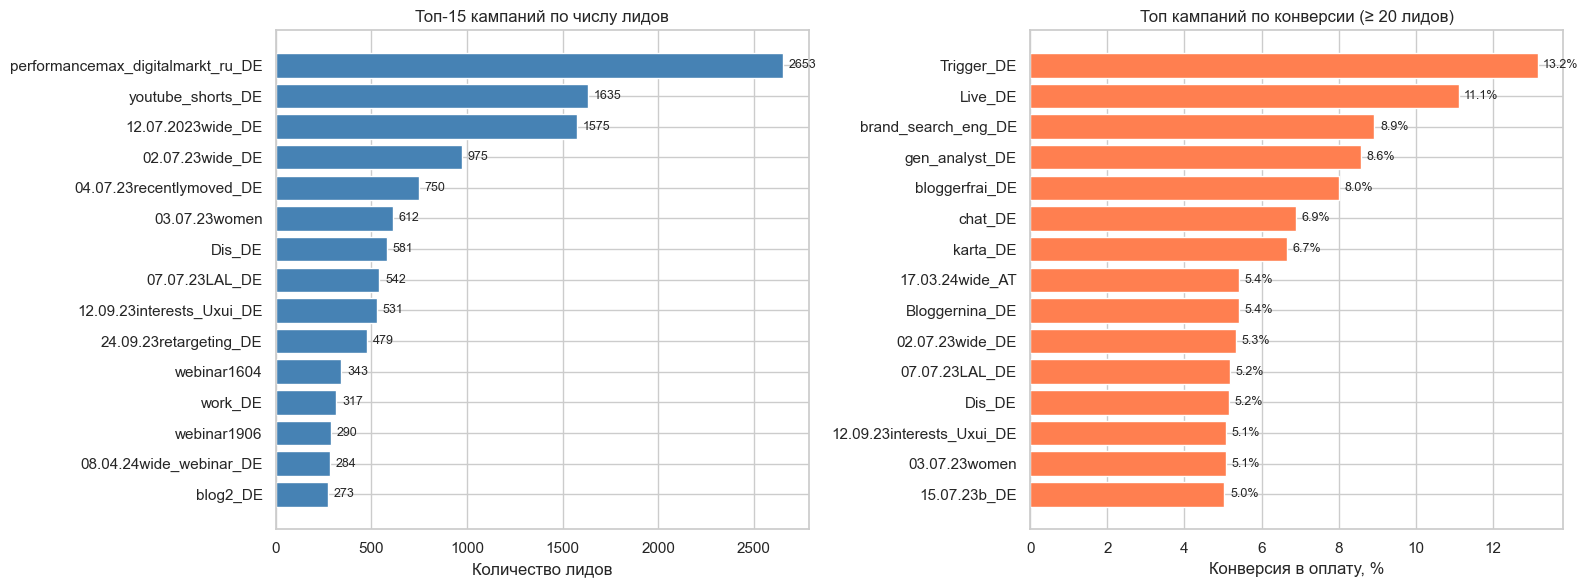

In [17]:
# Топ-15 кампаний по числу лидов — визуализация
top15_campaigns = campaign_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый: лиды по кампаниям
bars = axes[0].barh(top15_campaigns['Campaign'][::-1],
                    top15_campaigns['Лидов'][::-1], color='steelblue')
axes[0].set_title('Топ-15 кампаний по числу лидов')
axes[0].set_xlabel('Количество лидов')
axes[0].bar_label(bars, fmt='%d', padding=4, fontsize=9)

# Правый: конверсия (только кампании с ≥ 20 лидами)
conv_campaigns = campaign_stats[campaign_stats['Лидов'] >= 20].sort_values(
    'Конверсия %', ascending=False).head(15)

bars2 = axes[1].barh(conv_campaigns['Campaign'][::-1],
                     conv_campaigns['Конверсия %'][::-1], color='coral')
axes[1].set_title('Топ кампаний по конверсии (≥ 20 лидов)')
axes[1].set_xlabel('Конверсия в оплату, %')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS + 'campaign_analysis.png', dpi=100)
plt.show()


In [18]:
# Лучшие кампании по конверсии (минимум 20 лидов)
top_conv = campaign_stats[campaign_stats['Лидов'] >= 20].sort_values(
    'Конверсия %', ascending=False).head(10)
print('Лучшие кампании по конверсии (≥ 20 лидов):')
print(top_conv.to_string(index=False))


Лучшие кампании по конверсии (≥ 20 лидов):
           Campaign  Лидов  Оплат  Конверсия %
         Trigger_DE   38.0    5.0        13.16
            Live_DE   27.0    3.0        11.11
brand_search_eng_DE  168.0   15.0         8.93
     gen_analyst_DE   35.0    3.0         8.57
     bloggerfrai_DE   25.0    2.0         8.00
            chat_DE   29.0    2.0         6.90
           karta_DE   30.0    2.0         6.67
    17.03.24wide_AT   37.0    2.0         5.41
     Bloggernina_DE   37.0    2.0         5.41
    02.07.23wide_DE  975.0   52.0         5.33


## 6. Источники трафика: качество лидов

Смотрим, какие источники приносят «горячих» лидов (Quality A/B),
а какие — нецелевой трафик (D/E). Это ключ к оптимизации бюджета.


In [19]:
# Разделяем лиды на «качественные» и «нецелевые»
quality_map = {
    'A - High': 'Качественные (A+B)',
    'B - Medium': 'Качественные (A+B)',
    'C - Low': 'Средние (C)',
    'D - Non Target': 'Нецелевые (D+E)',
    'E - Non Qualified': 'Нецелевые (D+E)'
}
deals['Quality Group'] = deals['Quality'].map(quality_map)

# Доля по группам качества для каждого источника
source_quality = (
    deals[deals['Quality'].notna() & deals['Source'].notna()]
    .groupby(['Source', 'Quality Group'])
    .size()
    .unstack(fill_value=0)
)

# Добавляем % качественных лидов
if 'Качественные (A+B)' in source_quality.columns:
    source_quality['% качественных'] = (
        source_quality['Качественные (A+B)'] /
        source_quality.sum(axis=1) * 100
    ).round(1)

source_quality['Всего'] = source_quality.sum(axis=1)
source_quality = source_quality.sort_values('Всего', ascending=False)
print(source_quality.to_string())


Quality Group   Качественные (A+B)  Нецелевые (D+E)  Средние (C)  % качественных   Всего
Source                                                                                  
Facebook Ads                   584             2998          896            13.0  4491.0
Google Ads                     405             3104          692             9.6  4210.6
Organic                        276             1829          318            11.4  2434.4
Tiktok Ads                     121             1325          354             6.7  1806.7
Youtube Ads                    129             1213          301             7.9  1650.9
SMM                            165             1041          344            10.6  1560.6
Telegram posts                 108              699          186            10.9  1003.9
Bloggers                       105              685          200            10.6  1000.6
CRM                             40              553           96             5.8   694.8
Webinar              

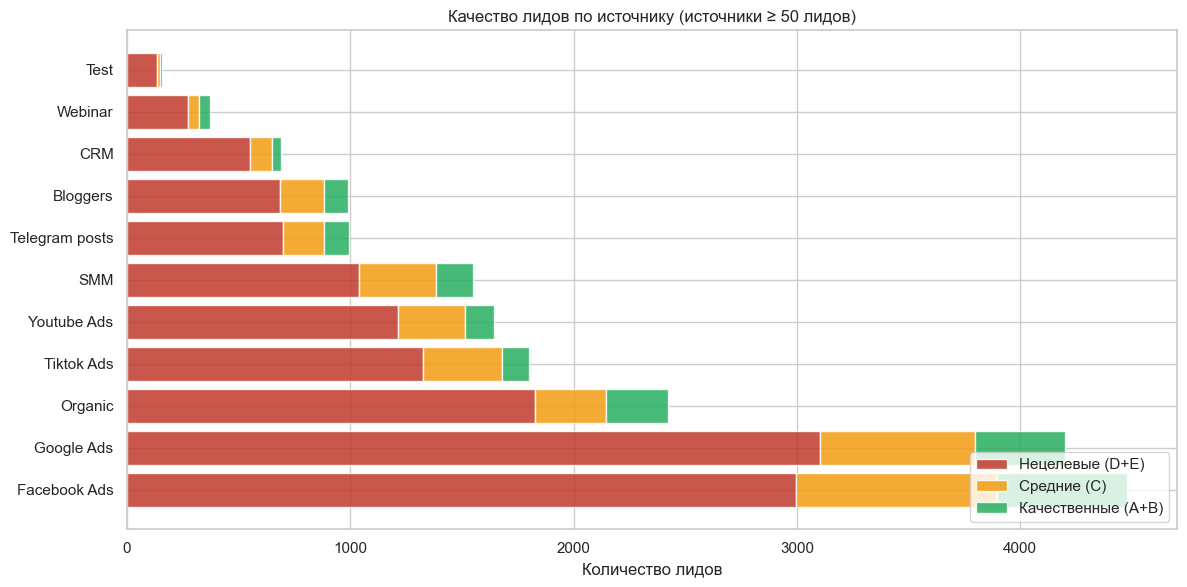

In [20]:
# Визуализация: стекированный барчарт по источникам
sq_plot = source_quality.drop(columns=['Всего', '% качественных'],
                               errors='ignore')
sq_plot = sq_plot[sq_plot.sum(axis=1) >= 50]  # только крупные источники

colors_stack = {'Качественные (A+B)': '#27ae60',
                'Средние (C)': '#f39c12',
                'Нецелевые (D+E)': '#c0392b'}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(sq_plot))

for col in ['Нецелевые (D+E)', 'Средние (C)', 'Качественные (A+B)']:
    if col in sq_plot.columns:
        values = sq_plot[col].values
        ax.barh(sq_plot.index, values, left=bottom,
                color=colors_stack.get(col, 'gray'), label=col, alpha=0.85)
        bottom += values

ax.set_title('Качество лидов по источнику (источники ≥ 50 лидов)')
ax.set_xlabel('Количество лидов')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PLOTS + 'source_quality_breakdown.png', dpi=100)
plt.show()


In [21]:
# Рейтинг источников по % качественных лидов
if '% качественных' in source_quality.columns:
    quality_rank = (source_quality[source_quality['Всего'] >= 50]
                    ['% качественных']
                    .sort_values(ascending=False))
    print('% качественных лидов (A+B) по источнику (≥ 50 лидов):')
    print(quality_rank.to_string())


% качественных лидов (A+B) по источнику (≥ 50 лидов):
Source
Partnership       16.2
Facebook Ads      13.0
Webinar           12.9
Organic           11.4
Telegram posts    10.9
SMM               10.6
Bloggers          10.6
Google Ads         9.6
Youtube Ads        7.9
Tiktok Ads         6.7
CRM                5.8
Test               5.7


## 7. Анализ отдела продаж (менеджеры)

Оцениваем каждого менеджера по трём критериям:
количество сделок, конверсия в оплату и суммарная выручка.


In [22]:
# Убираем строки без менеджера
with_owner = deals[deals['Deal Owner Name'].notna()].copy()

# Агрегируем по менеджерам
manager_stats = (
    with_owner.groupby('Deal Owner Name')
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2),
        'Выручка': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()
            & (~x['Initial Amount Paid'].isin([0, 1, 9])),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
    .sort_values('Конверсия %', ascending=False)
)

print('Статистика менеджеров (сортировка по конверсии):')
print(manager_stats.to_string(index=False))


Статистика менеджеров (сортировка по конверсии):
Deal Owner Name  Сделок  Оплат  Конверсия %  Выручка
  Oliver Taylor   163.0   50.0        30.67  50250.0
   Kevin Parker   574.0   40.0         6.97  23950.0
  Ulysses Adams  2165.0  141.0         6.51 127100.0
       John Doe    20.0    1.0         5.00      0.0
  Charlie Davis  2963.0  148.0         4.99 141750.0
Paula Underwood  1862.0   93.0         4.99 101650.0
   Julia Nelson  2241.0   93.0         4.15  85050.0
       Eva Kent   459.0   18.0         3.92  20100.0
     Nina Scott  1283.0   46.0         3.59  40700.0
  Victor Barnes  1232.0   44.0         3.57  66700.0
 Quincy Vincent  1884.0   65.0         3.45  72400.0
       Ben Hall  1345.0   46.0         3.42  58700.0
     Jane Smith   988.0   31.0         3.14  27200.0
   Cara Iverson  1056.0   27.0         2.56 151900.0
    George King    94.0    2.0         2.13    900.0
     Ian Miller   497.0    8.0         1.61   8050.0
  Mason Roberts   268.0    3.0         1.12   1900

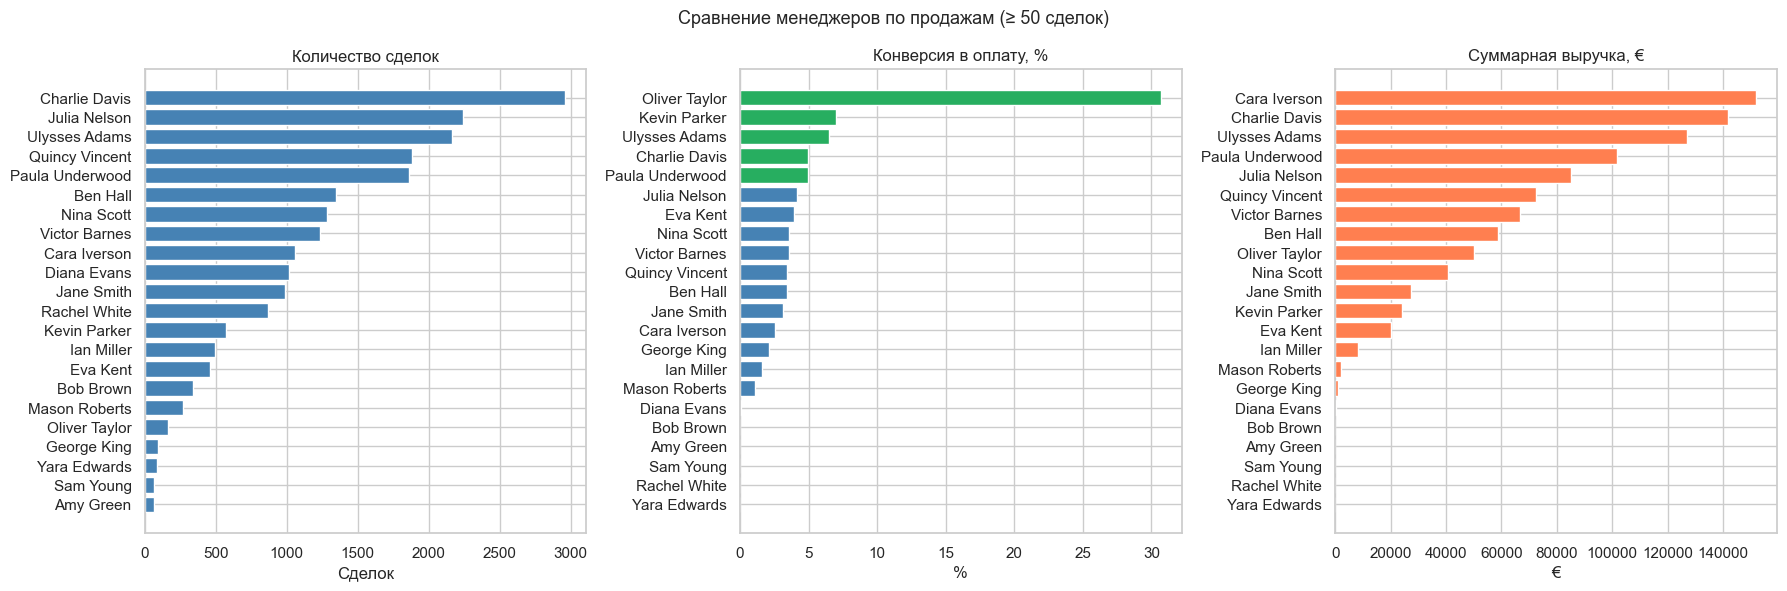

In [23]:
# Топ и антитоп по конверсии — только менеджеры с ≥ 50 сделок
active_managers = manager_stats[manager_stats['Сделок'] >= 50].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: число сделок
sorted_by_deals = active_managers.sort_values('Сделок', ascending=False)
axes[0].barh(sorted_by_deals['Deal Owner Name'][::-1],
             sorted_by_deals['Сделок'][::-1], color='steelblue')
axes[0].set_title('Количество сделок')
axes[0].set_xlabel('Сделок')

# График 2: конверсия
sorted_by_conv = active_managers.sort_values('Конверсия %', ascending=False)
colors_conv = ['#27ae60' if i < 5 else ('#c0392b' if i >= len(sorted_by_conv) - 3
               else 'steelblue')
               for i in range(len(sorted_by_conv))]
axes[1].barh(sorted_by_conv['Deal Owner Name'][::-1],
             sorted_by_conv['Конверсия %'][::-1],
             color=colors_conv[::-1])
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_xlabel('%')

# График 3: выручка
sorted_by_rev = active_managers.sort_values('Выручка', ascending=False)
axes[2].barh(sorted_by_rev['Deal Owner Name'][::-1],
             sorted_by_rev['Выручка'][::-1], color='coral')
axes[2].set_title('Суммарная выручка, €')
axes[2].set_xlabel('€')

plt.suptitle('Сравнение менеджеров по продажам (≥ 50 сделок)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'manager_comparison.png', dpi=100)
plt.show()


In [24]:
# Топ-3 и антитоп-3 по конверсии
top3 = active_managers.nlargest(3, 'Конверсия %')
bot3 = active_managers.nsmallest(3, 'Конверсия %')

print('ТОП-3 менеджера по конверсии:')
print(top3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))
print()
print('АНТИТОП-3 менеджера по конверсии:')
print(bot3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))


ТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
  Oliver Taylor   163.0   50.0        30.67
   Kevin Parker   574.0   40.0         6.97
  Ulysses Adams  2165.0  141.0         6.51

АНТИТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
      Bob Brown   337.0    0.0          0.0
      Amy Green    66.0    0.0          0.0
      Sam Young    67.0    0.0          0.0


In [25]:
# Разброс конверсии — есть ли значимые различия между менеджерами?
conv_std = active_managers['Конверсия %'].std()
conv_mean = active_managers['Конверсия %'].mean()
print(f'Средняя конверсия по менеджерам: {conv_mean:.2f}%')
print(f'Стандартное отклонение:          {conv_std:.2f}%')
print()
print('Вывод: если разброс велик — потенциал роста через обмен')
print('лучшими практиками между топ- и антитоп-менеджерами.')


Средняя конверсия по менеджерам: 3.95%
Стандартное отклонение:          6.34%

Вывод: если разброс велик — потенциал роста через обмен
лучшими практиками между топ- и антитоп-менеджерами.


## 8. Продукты и платежи

### 8.1 Выручка и конверсия по продуктам

In [26]:
# Анализируем только сделки с заполненным продуктом
with_product = deals[deals['Product'].notna()].copy()

product_stats = (
    with_product.groupby('Product')
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2),
        'Средний чек': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()
            & (~x['Initial Amount Paid'].isin([0, 1, 9])),
            'Initial Amount Paid'
        ].median()
    }), include_groups=False)
    .reset_index()
    .sort_values('Оплат', ascending=False)
)

print('Статистика по продуктам:')
print(product_stats.to_string(index=False))


Статистика по продуктам:
            Product  Сделок  Оплат  Конверсия %  Средний чек
  Digital Marketing  1990.0  474.0        23.82       1000.0
       UX/UI Design  1022.0  229.0        22.41       1000.0
      Web Developer   575.0  137.0        23.83       1000.0
Find yourself in IT     4.0    1.0        25.00          NaN
     Data Analytics     1.0    0.0         0.00          NaN


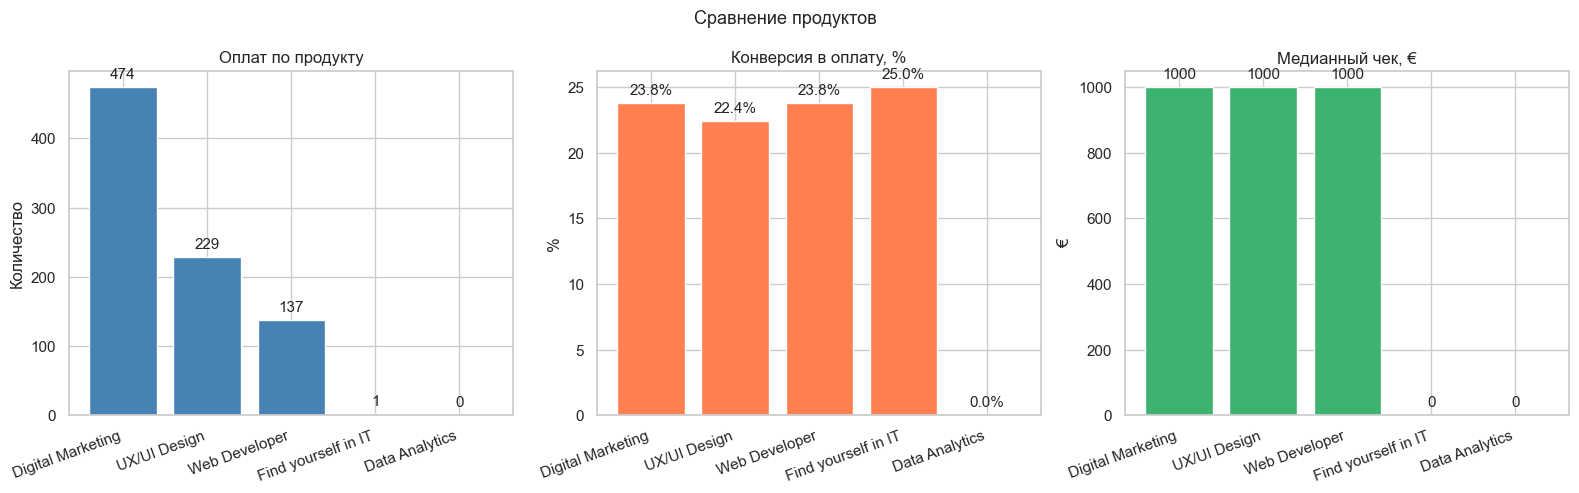

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Число оплат по продукту
bars0 = axes[0].bar(product_stats['Product'], product_stats['Оплат'],
                    color='steelblue')
axes[0].set_title('Оплат по продукту')
axes[0].set_ylabel('Количество')
axes[0].bar_label(bars0, fmt='%d', padding=4)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Конверсия по продукту
bars1 = axes[1].bar(product_stats['Product'], product_stats['Конверсия %'],
                    color='coral')
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_ylabel('%')
axes[1].bar_label(bars1, fmt='%.1f%%', padding=4)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Средний чек по продукту
bars2 = axes[2].bar(product_stats['Product'],
                    product_stats['Средний чек'].fillna(0),
                    color='mediumseagreen')
axes[2].set_title('Медианный чек, €')
axes[2].set_ylabel('€')
axes[2].bar_label(bars2, fmt='%.0f', padding=4)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.suptitle('Сравнение продуктов', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'product_comparison.png', dpi=100)
plt.show()


### 8.2 Причины потери сделок (Lost Reason)

In [28]:
# Lost Reason — ключ к пониманию, почему клиенты уходят
lost_deals = deals[deals['Stage'] == 'Lost']
lost_reason = lost_deals['Lost Reason'].value_counts()

print('Причины потери сделок:')
print(lost_reason.to_string())


Причины потери сделок:
Lost Reason
Doesn't Answer                             4074
Changed Decision                           2122
Duplicate                                  1746
Non target                                 1736
Stopped Answering                          1556
Invalid number                             1460
Expensive                                   614
needs time to think                         606
Conditions are not suitable                 524
Inadequate                                  174
Gutstein refusal                            163
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Next stream                                 131
Didn't leave an application                 131
Thought for free                            110
Does not know how to use a computer          49
Went to Rivals                               47
The contract did not fit                     21
Refug

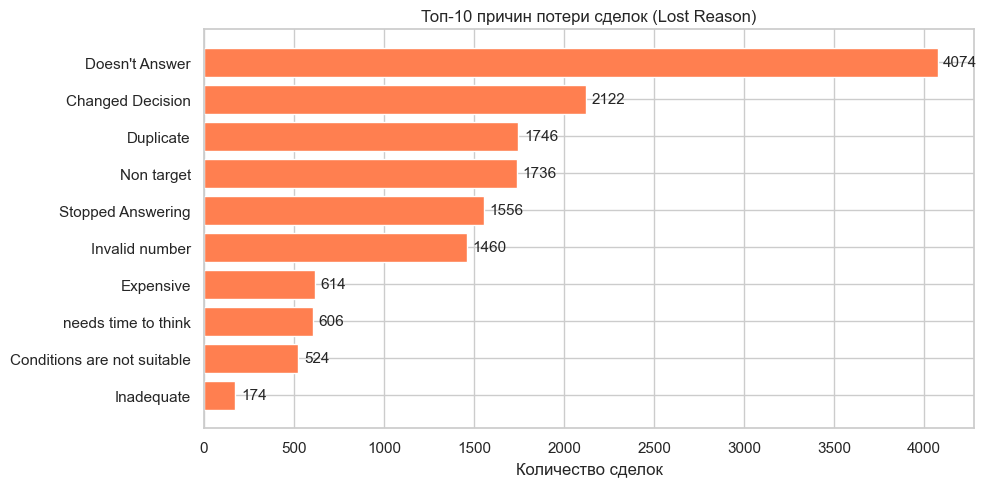

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

top_reasons = lost_reason.head(10)
bars = ax.barh(top_reasons.index[::-1], top_reasons.values[::-1], color='coral')
ax.set_title('Топ-10 причин потери сделок (Lost Reason)')
ax.set_xlabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig(PLOTS + 'lost_reasons.png', dpi=100)
plt.show()


In [30]:
# Доля каждой причины
total_lost = len(lost_deals)
print('Причины потери сделок (%):')
for reason, count in lost_reason.head(8).items():
    print(f'  {reason}: {count} ({count/total_lost:.1%})')
print()
print('Вывод: «Не отвечает» — главная причина потери.')
print('Это указывает на проблему с качеством лидов или скоростью обработки.')


Причины потери сделок (%):
  Doesn't Answer: 4074 (25.9%)
  Changed Decision: 2122 (13.5%)
  Duplicate: 1746 (11.1%)
  Non target: 1736 (11.0%)
  Stopped Answering: 1556 (9.9%)
  Invalid number: 1460 (9.3%)
  Expensive: 614 (3.9%)
  needs time to think: 606 (3.8%)

Вывод: «Не отвечает» — главная причина потери.
Это указывает на проблему с качеством лидов или скоростью обработки.


## 9. География: города и уровень немецкого

Смотрим географическое распределение лидов
и влияние уровня немецкого языка на успешность сделок.


In [31]:
# Сделки по городам — только с заполненным городом
city_deals = deals[deals['City'].notna()].copy()

city_stats = (
    city_deals.groupby('City')
    .apply(lambda x: pd.Series({
        'Лидов': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False)
    .reset_index()
    .sort_values('Лидов', ascending=False)
)

print('Топ-20 городов по числу лидов:')
print(city_stats.head(20).to_string(index=False))


Топ-20 городов по числу лидов:
                  City  Лидов  Оплат  Конверсия %
                Berlin  182.0   78.0        42.86
               München   74.0   27.0        36.49
               Hamburg   62.0   22.0        35.48
              Nürnberg   45.0    9.0        20.00
               Leipzig   45.0   18.0        40.00
            Düsseldorf   33.0    7.0        21.21
               Dresden   28.0    9.0        32.14
             Frankfurt   27.0    7.0        25.93
              Dortmund   26.0    4.0        15.38
                  Köln   25.0    9.0        36.00
             Stuttgart   20.0    2.0        10.00
              Hannover   19.0    4.0        21.05
              Duisburg   19.0    5.0        26.32
                Bremen   17.0    5.0        29.41
             Karlsruhe   16.0    4.0        25.00
                 Essen   16.0    6.0        37.50
                Bochum   15.0    5.0        33.33
Villingen-Schwenningen   14.0    6.0        42.86
              Augsb

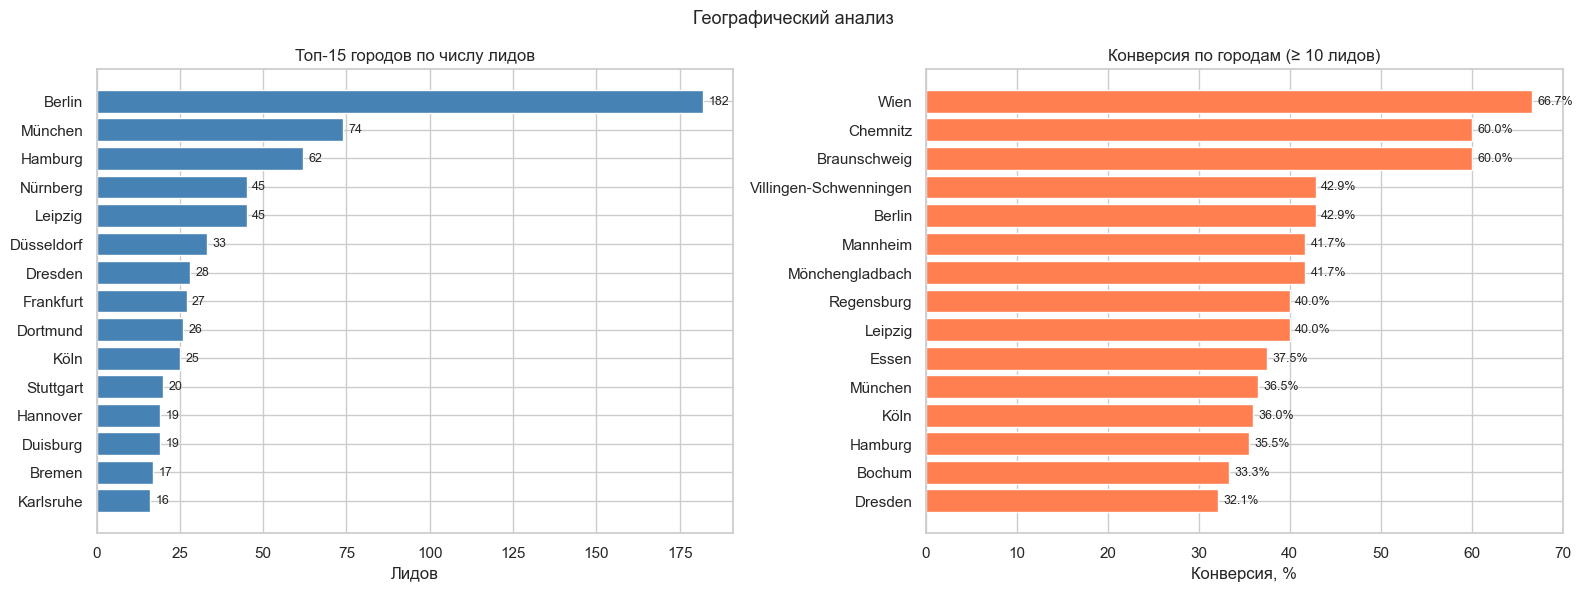

In [32]:
top_cities = city_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Лиды по городам
bars0 = axes[0].barh(top_cities['City'][::-1],
                     top_cities['Лидов'][::-1], color='steelblue')
axes[0].set_title('Топ-15 городов по числу лидов')
axes[0].set_xlabel('Лидов')
axes[0].bar_label(bars0, fmt='%d', padding=4, fontsize=9)

# Конверсия по городам (только с ≥ 10 лидами)
city_conv = city_stats[city_stats['Лидов'] >= 10].sort_values(
    'Конверсия %', ascending=False).head(15)
bars1 = axes[1].barh(city_conv['City'][::-1],
                     city_conv['Конверсия %'][::-1], color='coral')
axes[1].set_title('Конверсия по городам (≥ 10 лидов)')
axes[1].set_xlabel('Конверсия, %')
axes[1].bar_label(bars1, fmt='%.1f%%', padding=4, fontsize=9)

plt.suptitle('Географический анализ', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'geo_analysis.png', dpi=100)
plt.show()


### 9.2 Уровень немецкого и конверсия

In [35]:
print('Вывод: анализируем, есть ли корреляция между уровнем немецкого и')
print('вероятностью оплаты. Если уровень B1+ конвертируется лучше —')
print('это сигнал для таргетинга на более продвинутых студентов.')


Вывод: анализируем, есть ли корреляция между уровнем немецкого и
вероятностью оплаты. Если уровень B1+ конвертируется лучше —
это сигнал для таргетинга на более продвинутых студентов.


## 10. Сводные бизнес-выводы

In [36]:
print('=== Ключевые выводы анализа (Этап 3) ===')
print()

# Лучший месяц по лидам
peak = monthly_deals.loc[monthly_deals['Deals Count'].idxmax()]
print(f'Пик привлечения лидов: {peak["Month"].strftime("%B %Y")} — '
      f'{peak["Deals Count"]} сделок')

# Лучшая кампания
if len(campaign_stats) > 0:
    best_campaign = campaign_stats[campaign_stats['Лидов'] >= 20].nlargest(
        1, 'Конверсия %').iloc[0]
    print(f'Лучшая кампания по конверсии: {best_campaign["Campaign"]} '
          f'({best_campaign["Конверсия %"]}%)')

# Лучший менеджер
if len(active_managers) > 0:
    best_mgr = active_managers.nlargest(1, 'Конверсия %').iloc[0]
    print(f'Лучший менеджер: {best_mgr["Deal Owner Name"]} '
          f'({best_mgr["Конверсия %"]}% конверсия)')

# Лучший продукт
if len(product_stats) > 0:
    best_prod = product_stats.nlargest(1, 'Конверсия %').iloc[0]
    print(f'Лучший продукт по конверсии: {best_prod["Product"]} '
          f'({best_prod["Конверсия %"]}%)')

# Топ причина потери
top_lost_reason = lost_reason.index[0]
top_lost_pct = lost_reason.iloc[0] / total_lost
print(f'Главная причина потери: «{top_lost_reason}» ({top_lost_pct:.1%})')


=== Ключевые выводы анализа (Этап 3) ===

Пик привлечения лидов: April 2024 — 3082 сделок
Лучшая кампания по конверсии: Trigger_DE (13.16%)
Лучший менеджер: Oliver Taylor (30.67% конверсия)
Лучший продукт по конверсии: Find yourself in IT (25.0%)
Главная причина потери: «Doesn't Answer» (25.9%)


### Итоговые рекомендации

1. **Временные ряды**: пик лидов — летний период; конверсия нестабильна по месяцам.
   → Стоит усиливать обработку лидов в пиковые периоды.

2. **Кампании**: небольшие кампании с высокой конверсией существуют —
   их стоит масштабировать. Крупные по объёму кампании не всегда самые эффективные.

3. **Источники**: органика и CRM дают качественных лидов (высокий % A+B),
   платный трафик — больше нецелевых (D+E).

4. **Менеджеры**: значительный разброс конверсии между сотрудниками —
   потенциал роста через обмен лучшими практиками.

5. **Продукты**: Digital Marketing лидирует по объёму,
   но не обязательно по рентабельности.

6. **Lost Reason**: «Не отвечает» — главная причина. Нужен быстрый первый контакт
   (связь с показателем SLA из этапа 2).

7. **География**: Berlin, München, Hamburg — топ-3 города. Возможности для
   гео-таргетинга кампаний по наиболее конвертируемым городам.

---
*Следующий этап: `04_unit_economics.ipynb` — CAC, ARPPU, юнит-экономика по продуктам.*
